# Std

Classification Report
              precision    recall  f1-score   support

           0      0.975     0.803     0.880     50951
           1      0.230     0.739     0.350      4049

    accuracy                          0.798     55000
   macro avg      0.602     0.771     0.615     55000
weighted avg      0.920     0.798     0.841     55000

Confusion Matrix:
Predicted      0      1
Actual                 
0          40901  10050
1           1055   2994
ROC AUC: 0.8518
Average Precision: 0.4258


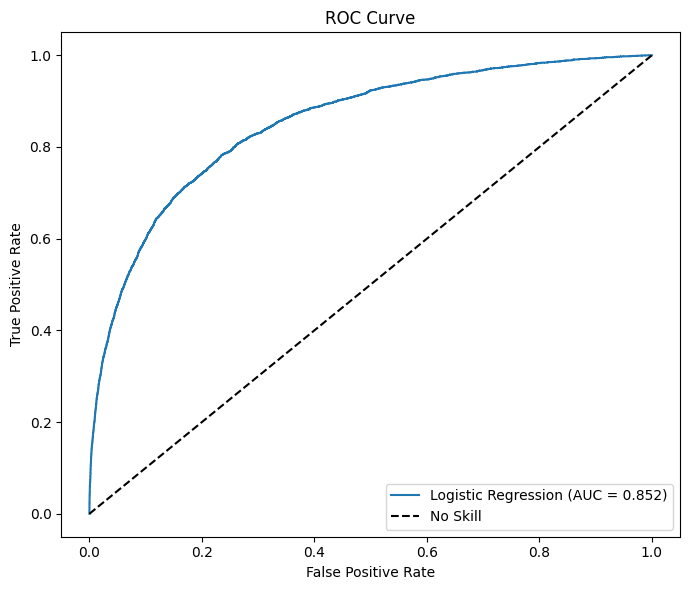

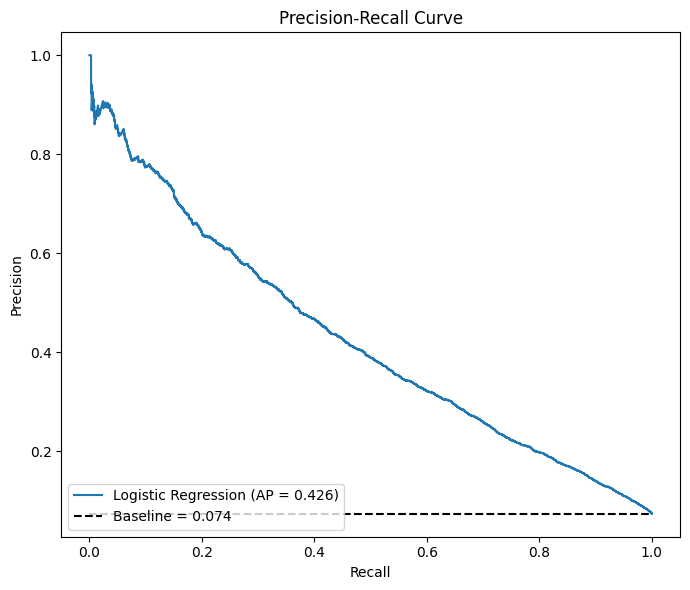

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)

# =========================
# 1. Load data
# =========================
csv_path = r"..\Data\SyntheticData\2026_03_31_01_52_14\std_synthetic_data_2026_03_31_01_52_14.csv"  # change if needed
df = pd.read_csv(csv_path)

# =========================
# 2. Build features / target
# =========================
target = "Problem_SKU"

# one-hot encode Storage_Size
size_dummies = pd.get_dummies(df["Storage_Size"], prefix="Size", drop_first=True)

# binary encode
defect_linked_num = df["Defect_In_Linked_Receive"].astype(int)

numeric_features = [
    "Global_SKU_Defect_Rate_%_std",
    "ABS_Volume_Difference_std",
    "Aisle_Hold_%_std",
    "#_Pick_Events_std",
    "#_Pick_Events_In_Clique_std",
    "#_Picks_std",
    "#_Picks_In_Clique_std",
    "Time_In_Loc_std",
    "Current_Max_Volume_std",
]



X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

# =========================
# 3. Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Fit logistic regression
# =========================
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# 5. Predict probabilities
# =========================
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, digits=3))
print(f"Confusion Matrix:\n{pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")

# =========================
# 6. ROC curve
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# =========================
# 7. Precision-Recall curve
# =========================
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Logistic Regression (AP = {ap:.3f})")
baseline = y_test.mean()
plt.plot([0, 1], [baseline, baseline], "k--", label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


# Raw

c:\Users\myfir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report
              precision    recall  f1-score   support

           0      0.975     0.785     0.870     50966
           1      0.215     0.747     0.334      4034

    accuracy                          0.782     55000
   macro avg      0.595     0.766     0.602     55000
weighted avg      0.919     0.782     0.830     55000

Confusion Matrix:
Predicted      0      1
Actual                 
0          39992  10974
1           1021   3013
ROC AUC: 0.8399
Average Precision: 0.4121


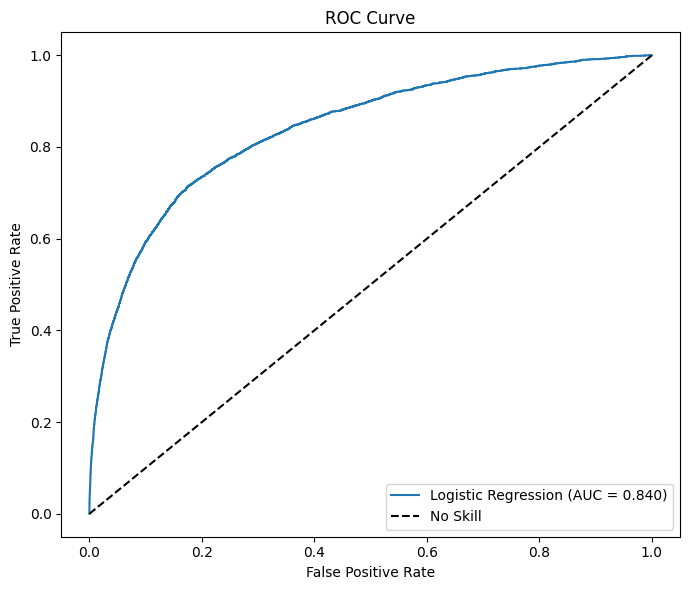

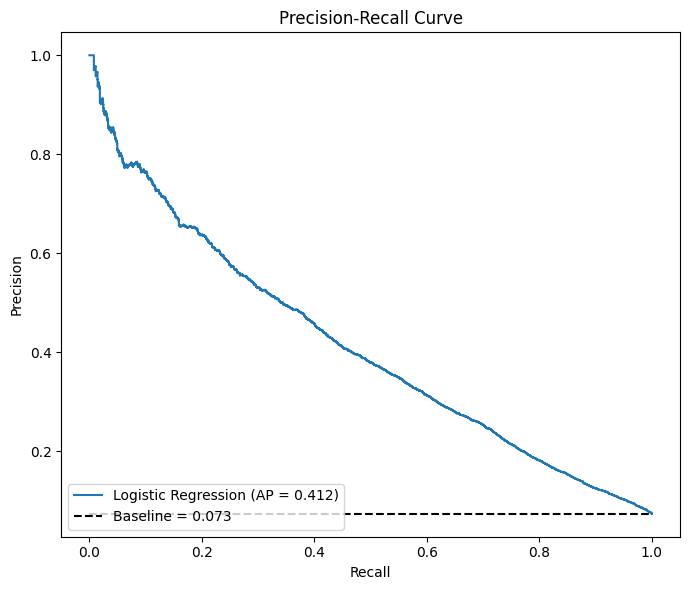

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)

# =========================
# 1. Load data
# =========================
csv_path = r"..\Data\SyntheticData\2026_03_31_01_52_14\synthetic_data_2026_03_31_01_52_14.csv"  # change if needed
df = pd.read_csv(csv_path)

# =========================
# 2. Build features / target
# =========================
target = "Problem_SKU"

# one-hot encode Storage_Size
size_dummies = pd.get_dummies(df["Storage_Size"], prefix="Size", drop_first=True)

# binary encode
defect_linked_num = df["Defect_In_Linked_Receive"].astype(int)

numeric_features = [
    "Global_SKU_Defect_Rate_%",
    "ABS_Volume_Difference",
    "Aisle_Hold_%",
    "#_Pick_Events",
    "#_Pick_Events_In_Clique",
    "#_Picks",
    "#_Picks_In_Clique",
    "Time_In_Loc",
    "Current_Max_Volume",
]



X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

# =========================
# 3. Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Fit logistic regression
# =========================
model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

# =========================
# 5. Predict probabilities
# =========================
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print("Classification Report")
print(classification_report(y_test, y_pred, digits=3))
print(f"Confusion Matrix:\n{pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")

# =========================
# 6. ROC curve
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# =========================
# 7. Precision-Recall curve
# =========================
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Logistic Regression (AP = {ap:.3f})")
baseline = y_test.mean()
plt.plot([0, 1], [baseline, baseline], "k--", label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


c:\Users\myfir\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report
              precision    recall  f1-score   support

           0      0.976     0.793     0.875     50966
           1      0.224     0.753     0.345      4034

    accuracy                          0.790     55000
   macro avg      0.600     0.773     0.610     55000
weighted avg      0.921     0.790     0.836     55000

Confusion Matrix:
Predicted      0      1
Actual                 
0          40431  10535
1            995   3039
ROC AUC: 0.8444
Average Precision: 0.4198
Number of features with interactions: 91


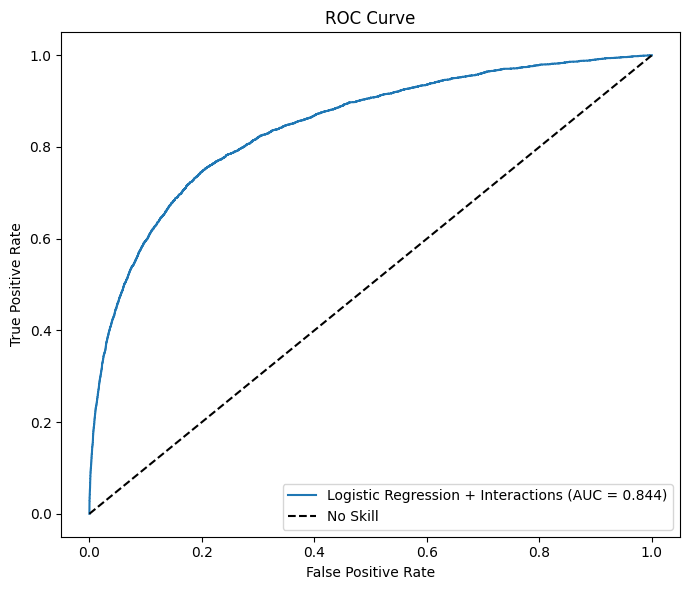

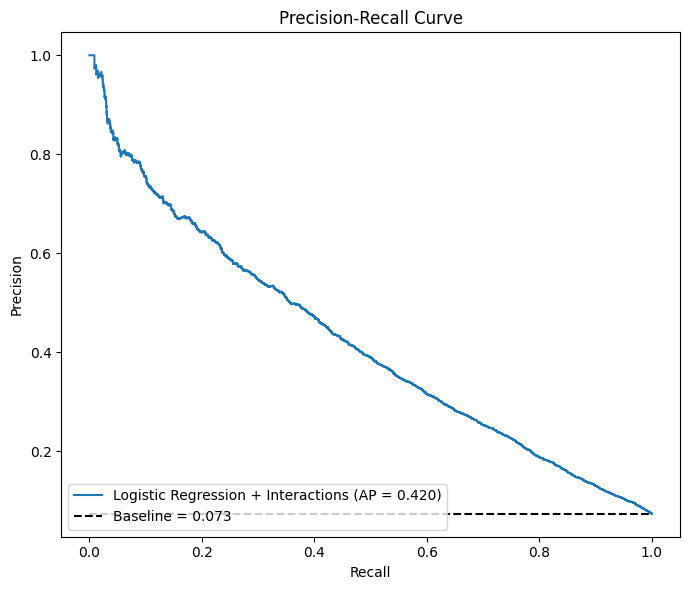

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# =========================
# 1. Load data
# =========================
csv_path = r"..\Data\SyntheticData\2026_03_31_01_52_14\synthetic_data_2026_03_31_01_52_14.csv"  # change if needed
df = pd.read_csv(csv_path)

# =========================
# 2. Build features / target
# =========================
target = "Problem_SKU"

# one-hot encode Storage_Size
size_dummies = pd.get_dummies(df["Storage_Size"], prefix="Size", drop_first=True)

# binary encode
defect_linked_num = df["Defect_In_Linked_Receive"].astype(int)

numeric_features = [
    "Global_SKU_Defect_Rate_%",
    "ABS_Volume_Difference",
    "Aisle_Hold_%",
    "#_Pick_Events",
    "#_Pick_Events_In_Clique",
    "#_Picks",
    "#_Picks_In_Clique",
    "Time_In_Loc",
    "Current_Max_Volume",
]

X = pd.concat([df[numeric_features], size_dummies, defect_linked_num], axis=1)
y = df[target].astype(int)

# =========================
# 3. Train/test split (BEFORE interactions)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# 4. Create interactions + fit model
# =========================
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

# Option 1: Manual pipeline (recommended)
X_train_inter = poly.fit_transform(X_train)
X_test_inter = poly.transform(X_test)

model.fit(X_train_inter, y_train)

# =========================
# 5. Predict probabilities
# =========================
y_proba = model.predict_proba(X_test_inter)[:, 1]
y_pred = model.predict(X_test_inter)

print("Classification Report")
print(classification_report(y_test, y_pred, digits=3))
print(f"Confusion Matrix:\n{pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])}")
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")
print(f"Number of features with interactions: {X_train_inter.shape[1]}")

# =========================
# 6. ROC curve
# =========================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression + Interactions (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# =========================
# 7. Precision-Recall curve
# =========================
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f"Logistic Regression + Interactions (AP = {ap:.3f})")
baseline = y_test.mean()
plt.plot([0, 1], [baseline, baseline], "k--", label=f"Baseline = {baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()